In [1]:
import math
import random
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats
import itertools
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from matplotlib import cm
import matplotlib 
%matplotlib inline

In [67]:
# data from https://docs.google.com/spreadsheets/d/100QgXtkE5FHj-EFaa64HkjYu8EddSB07/edit#gid=1566829729

# cell line IDs w/o spike-ins 2, 3 and mt4-2D
clIDs = ['GATC', 'AAGG', 'ACAC', 'ACCT', 'ACGA', 'ACTG', 'AGAG', 'AGCA', 'AGGT', 'AGTC', 'ATCG', 'ATGC', 'CAAC', 'CACT', 'CAGA', 'CATG', 'CCAA', 'CCTT', 'CGAT', 'CGTA', 'CTGT', 'CTTC', 'GAAG', 'GCAT', 'GCTA', 'GGAA', 'GGTT', 'GTAC', 'GTGA', 'GTTG', 'TCCA', 'TGAC', 'TTCC', 'TTGG']

# cell lines w/o spike-ins 2, 3 and mt4-2D; added numbers (1 and 2) to cell lines w/ identical names
# IT IS IMPORTANT THAT THE SPIKE-IN IS FIRST 
cell_lines = ['Spike-in 1', '7160c2', 'FC1199', '6694c2', '7160c5', 'BF857', 'BF1987', 'Panc2', '0688_M', 'FC1245-1', 'BF4326-1', 'BF2117', '6419c5', 'BF4326-2', 'UN-KPC_960-1', '0755_Pancreas', 'BF1836', 'BF2014', 'BF5960', '6499c4', '6422c5', 'FC1245-2', 'KPC_cell_line', 'UN-KPC_960-2', 'BF2153', 'UN-KC-6141', 'mT3-2D', 'mT5-2D', '0764_Pancreas', '6421c2', '0755_Ascites', '2838c3', 'FC1242', 'UN-KPC_961']

clID_dict = dict(zip(clIDs, cell_lines))
cell_line_dict = dict(zip(cell_lines, clIDs))

# pre-injection samples
samples_pre_inj_path = '/Users/alyulina/Projects/Cancer/Data/cell-line-level/pre-inj/'

samples_pre_inj = ['SK1_61', 'SK1_62', 'SK1_63']

# 2d samples (iv)
samples_2d_path = '/Users/alyulina/Projects/Cancer/Data/cell-line-level/2-day/'

# 'SK58_2', 'SK59_2', 'SK60_2' are PCR replicates; some samples are from the same mouse (A and B -- not sure what they are)
samples_iv_2d_f1_lung = ['SK1_51', 'SK1_52', 'SK1_53', 'SK1_54', 'SK1_55', 'SK1_56', 'SK1_57', 'SK1_58', 'SK1_59', 'SK1_60', 'SK1_58_2', 'SK1_59_2', 'SK1_60_2',
                         'LS01_01A', 'LS01_02A', 'LS01_01B', 'LS01_02B', 'LS01_03', 'LS01_04', 'LS01_05', 'LS01_06', 'LS01_07'] 

samples_iv_2d_rag1_lung = ['SK1_45', 'SK1_46', 'SK1_47', 'SK1_48', 'SK1_49', 'SK1_50']

# 3w samples (iv)
samples_3w_path = '/Users/alyulina/Projects/Cancer/Data/cell-line-level/3-week/'

samples_iv_3w_f1_lung = ['SK1_25', 'SK1_26', 'SK1_27', 'SK1_28', 'SK1_29', 'SK1_30', 'SK1_31', 'SK1_32', 'SK1_33', 'SK1_34', 
                         'SK1_35', 'SK1_36', 'SK1_37', 'SK1_38', 'SK1_39', 'SK1_40', 'SK1_41', 'SK1_42', 'SK1_43', 'SK1_44',
                         'LS01_35', 'LS01_36', 'LS01_37', 'LS01_38', 'LS01_39', 'LS01_40', 'LS01_41', 'LS01_42', 'LS01_43A', 'LS01_44A',
                         'LS01_43B', 'LS01_44B'] 

samples_iv_3w_f1_panc = ['LA67_1', 'LA67_2', 'LA67_3', 'LA67_4', 'LA67_5', 'LA67_6', 'LA67_7', 'LA67_8', 'LA67_9', 'LA67_10',
                         'LA67_11', 'LA67_12', 'LA67_13', 'LA67_14', 'LA67_15', 'LA67_16', 'LA67_17', 'LA67_18', 'LA67_19']

# excluded SK1_8, SK1_11, LS01_32
samples_iv_3w_rag1_lung = ['SK1_1', 'SK1_2', 'SK1_3', 'SK1_4', 'SK1_5', 'SK1_6', 'SK1_7', 'SK1_9', 'SK1_10', 
                           'SK1_12', 'SK1_13', 'SK1_14', 'SK1_15', 'SK1_16', 'SK1_17', 'SK1_18', 'SK1_19', 'SK1_20',
                           'SK1_21', 'SK1_22', 'SK1_23', 'SK1_24', 'LS01_27', 'LS01_28', 'LS01_29', 'LS01_30', 'LS01_31', 
                           'LS01_33', 'LS01_34']

# 3w samples (ip/is)
samples_transplant_path = '/Users/alyulina/Projects/Cancer/Data/cell-line-level/transplant/'

samples_ip_3w_f1_panc = ['SK1_94', 'SK94_2', 'SK1_95', 'SK95_2', 'SK96', 'SK97', 'SK98', 'SK1_99', 'SK99_2', 'SK100', 'SK101', 'SK102',
                         'LS01_17', 'LS01_18', 'LS01_19', 'LS01_20', 'LS01_21', 'LS01_22', 'LS01_23', 'LS01_24', 'LS01_25', 'LS01_26']


samples_is_3w_f1_liver = ['SK1_103', 'SK103_2', 'SK1_104', 'SK104_2', 'SK105', 'SK106', 'SK1_107', 'SK107_2', 'SK108', 'SK109', 'SK110',
                          'LS01_08', 'LS01_09', 'LS01_10', 'LS01_11', 'LS01_12', 'LS01_13', 'LS01_14', 'LS01_15', 'LS01_16']


samples_ip_3w_f1_fat = ['SK1_111', 'SK111_2', 'SK1_112', 'SK112_2', 'SK113', 'SK1_114', 'SK114_2', 'SK115', 'SK116'] 

# in vitro samples 
samples_in_vitro_path = '/Users/alyulina/Projects/Cancer/Data/cell-line-level/in-vitro/'
samples_in_vitro = ['SK1_64', 'SK1_65', 'SK1_66', 'SK1_67', 'SK1_68', 'SK1_69', 'SK1_70', 'SK1_71', 'SK1_72', 'SK1_73', 'SK1_74', 'SK1_75', 'SK1_76', 'SK1_77', 'SK1_78', 'SK1_79', 'SK1_80', 'SK1_81', 'SK1_82', 'SK1_83', 'SK1_84', 'SK1_85', 'SK1_86', 'SK1_87']

# all samples
samples_all = samples_pre_inj + samples_iv_2d_f1_lung + samples_iv_2d_rag1_lung + samples_iv_3w_f1_lung + samples_iv_3w_f1_panc + samples_iv_3w_rag1_lung + samples_ip_3w_f1_panc + samples_is_3w_f1_liver + samples_ip_3w_f1_fat + samples_in_vitro

In [68]:
# aggregate the number of reads for each cell line in each sample 
table = pd.DataFrame([[x] + [0 for y in samples_all] for x in clIDs], columns = ['clID'] + samples_all).set_index(['clID'])

In [69]:
pre_inj_cell_line_counts = {} # cell line counts in each sample
                              # there shouldn't be any spike-ins

for i in samples_pre_inj:
    
    with open(samples_pre_inj_path + i + '_clID_bc_extracted.txt') as f:
         found = f.read().split()[1::3]
    
    pre_inj_cell_line_counts[i] = dict([(x, found.count(x)) for x in set(found)])
    
    for j in clIDs:
        if j not in pre_inj_cell_line_counts[i]:
            continue
        table.loc[j, i] = pre_inj_cell_line_counts[i][j]

In [70]:
in_vitro_cell_line_counts = {} # cell line counts in each sample

for i in samples_in_vitro:
    
    with open(samples_in_vitro_path + i + '_clID_bc_extracted.txt') as f:
         found = f.read().split()[1::3]
    
    in_vitro_cell_line_counts[i] = dict([(x, found.count(x)) for x in set(found)])
    
    for j in clIDs:
        if j not in in_vitro_cell_line_counts[i]:
            continue
        table.loc[j, i] = in_vitro_cell_line_counts[i][j]

In [71]:
two_d_cell_line_counts = {} # cell line counts in each sample

for i in samples_iv_2d_f1_lung + samples_iv_2d_rag1_lung:
    
    with open(samples_2d_path + i + '_clID_bc_extracted.txt') as f:
         found = f.read().split()[1::3]
    
    two_d_cell_line_counts[i] = dict([(x, found.count(x)) for x in set(found)])
    
    for j in clIDs:
        if j not in two_d_cell_line_counts[i]:
            continue
        table.loc[j, i] = two_d_cell_line_counts[i][j]

In [72]:
three_w_cell_line_counts = {} # cell line counts in each sample

for i in samples_iv_3w_f1_lung + samples_iv_3w_f1_panc + samples_iv_3w_rag1_lung:
    
    with open(samples_3w_path + i + '_clID_bc_extracted.txt') as f:
         found = f.read().split()[1::3]
    
    three_w_cell_line_counts[i] = dict([(x, found.count(x)) for x in set(found)])
    
    for j in clIDs:
        if j not in three_w_cell_line_counts[i]:
            continue
        table.loc[j, i] = three_w_cell_line_counts[i][j]

In [73]:
transplant_cell_line_counts = {} # cell line counts in each sample

for i in samples_ip_3w_f1_panc + samples_is_3w_f1_liver + samples_ip_3w_f1_fat:
    
    with open(samples_transplant_path + i + '_clID_bc_extracted.txt') as f:
         found = f.read().split()[1::3]
    
    transplant_cell_line_counts[i] = dict([(x, found.count(x)) for x in set(found)])
    
    for j in clIDs:
        if j not in transplant_cell_line_counts[i]:
            continue
        table.loc[j, i] = transplant_cell_line_counts[i][j]

In [76]:
table;

In [75]:
#table.to_csv('../Data/cell-line-level/all_samples_clID_counts_updated.csv')  

In [77]:
# reading the cell line couts for each sample
n_reads = pd.read_csv('../Data/cell-line-level/all_samples_clID_counts_updated.csv', index_col=0)

In [89]:
n_reads;

In [99]:
# calculating avg pre-inj fracrions
avg_fracs_pre_inj = {}

for i in clIDs:
    if clID_dict[i] == 'Spike-in 1':
        continue
    
    fracs_i = []
    for j in samples_pre_inj:
        fracs_i.append(n_reads[j][i] / sum(n_reads[j][1:])) # normalizing by all excluding spike-in
    
    avg_fracs_pre_inj[i] = np.mean(fracs_i)

In [103]:
# calculating avg fracrions for other samples, UNWEIGHTED
# ideally, I'd look at each mouse separately before merging - NEED TO DO

avg_fracs_iv_2d_f1_lung = {}
for i in clIDs:
    if clID_dict[i] == 'Spike-in 1':
        continue
    fracs_i = []
    for j in samples_iv_2d_f1_lung:
        fracs_i.append(n_reads[j][i] / sum(n_reads[j][1:]))  
    avg_fracs_iv_2d_f1_lung[i] = np.mean(fracs_i)
    
    
avg_fracs_iv_2d_rag1_lung = {}
for i in clIDs:
    if clID_dict[i] == 'Spike-in 1':
        continue
    fracs_i = []
    for j in samples_iv_2d_rag1_lung:
        fracs_i.append(n_reads[j][i] / sum(n_reads[j][1:]))  
    avg_fracs_iv_2d_rag1_lung[i] = np.mean(fracs_i)
    
avg_fracs_iv_3w_f1_lung = {}
for i in clIDs:
    if clID_dict[i] == 'Spike-in 1':
        continue
    fracs_i = []
    for j in samples_iv_3w_f1_lung:
        fracs_i.append(n_reads[j][i] / sum(n_reads[j][1:]))  
    avg_fracs_iv_3w_f1_lung[i] = np.mean(fracs_i)
    
avg_fracs_iv_3w_f1_panc = {}
for i in clIDs:
    if clID_dict[i] == 'Spike-in 1':
        continue
    fracs_i = []
    for j in samples_iv_3w_f1_panc:
        fracs_i.append(n_reads[j][i] / sum(n_reads[j][1:]))  
    avg_fracs_iv_3w_f1_panc[i] = np.mean(fracs_i)
    
avg_fracs_iv_3w_rag1_lung = {}
for i in clIDs:
    if clID_dict[i] == 'Spike-in 1':
        continue
    fracs_i = []
    for j in samples_iv_3w_rag1_lung:
        fracs_i.append(n_reads[j][i] / sum(n_reads[j][1:]))  
    avg_fracs_iv_3w_rag1_lung[i] = np.mean(fracs_i)
    
avg_fracs_ip_3w_f1_panc = {}
for i in clIDs:
    if clID_dict[i] == 'Spike-in 1':
        continue
    fracs_i = []
    for j in samples_ip_3w_f1_panc:
        fracs_i.append(n_reads[j][i] / sum(n_reads[j][1:]))  
    avg_fracs_ip_3w_f1_panc[i] = np.mean(fracs_i)    
    
avg_fracs_is_3w_f1_liver = {}
for i in clIDs:
    if clID_dict[i] == 'Spike-in 1':
        continue
    fracs_i = []
    for j in samples_is_3w_f1_liver:
        fracs_i.append(n_reads[j][i] / sum(n_reads[j][1:]))  
    avg_fracs_is_3w_f1_liver[i] = np.mean(fracs_i)    
    
avg_fracs_ip_3w_f1_fat = {}
for i in clIDs:
    if clID_dict[i] == 'Spike-in 1':
        continue
    fracs_i = []
    for j in samples_ip_3w_f1_fat:
        fracs_i.append(n_reads[j][i] / sum(n_reads[j][1:]))  
    avg_fracs_ip_3w_f1_fat[i] = np.mean(fracs_i)

$$
\text{We can show that the weighted average of the fraction of cell line $i$ is equal to} 
\frac{\sum_j w_j \frac{r_{i,j}}{\sum_i r_{i,j}}}{\sum_j w_j} = \frac{\sum_j \frac{r_{i,j}}{R_j}}{\sum_{i,j} \frac{r_{i,j}}{R_j}}
\quad \text{if the weightning function $w_j$ is the number of cells in sample $j$: }
w_j = \frac{\sum_{i}r_{i,j}}{R_j}N, 
\quad \text{where $R_j$ is the number of spike-in reads in sample $j$. We can also see that the result is independent of $N$.} 
$$

In [121]:
# calculating avg fracrions for other samples, WEIGHTED

weighted_avg_fracs_iv_3w_f1_lung = {}
for i in clIDs:
    if clID_dict[i] == 'Spike-in 1':
        continue
        
    num = []; denom = [] # will need to sum over all samples 
    for j in samples_iv_3w_f1_lung:
        num.append(n_reads[j][i] / n_reads[j][0])
        denom.append(sum(n_reads[j][1:]) / n_reads[j][0]) # summing over i, excluding spike-in
    
    weighted_avg_fracs_iv_3w_f1_lung[i] = sum(num) / sum(denom) # summing over denom
    
    
weighted_avg_fracs_iv_3w_rag1_lung = {}
for i in clIDs:
    if clID_dict[i] == 'Spike-in 1':
        continue
        
    num = []; denom = [] # will need to sum over all samples 
    for j in samples_iv_3w_rag1_lung:
        num.append(n_reads[j][i] / n_reads[j][0])
        denom.append(sum(n_reads[j][1:]) / n_reads[j][0]) # summing over i, excluding spike-in
    
    weighted_avg_fracs_iv_3w_rag1_lung[i] = sum(num) / sum(denom) # summing over denom


    
weighted_avg_fracs_ip_3w_f1_fat = {}
for i in clIDs:
    if clID_dict[i] == 'Spike-in 1':
        continue
        
    num = []; denom = [] # will need to sum over all samples 
    for j in samples_ip_3w_f1_fat:
        num.append(n_reads[j][i] / n_reads[j][0])
        denom.append(sum(n_reads[j][1:]) / n_reads[j][0]) # summing over i, excluding spike-in
    
    weighted_avg_fracs_ip_3w_f1_fat[i] = sum(num) / sum(denom) # summing over denom


In [122]:
# ordering cell lines by avg 3w f1 iv lung weighted frac relative to pre-injection
tmp = []
for i in clIDs[1:]: # excluding spike-in
    tmp.append([i, weighted_avg_fracs_iv_3w_f1_lung[i] / avg_fracs_pre_inj[i]]) 

In [126]:
clIDs_ordered = [y[0] for y in sorted(tmp, key = lambda x: x[-1], reverse=True)]

In [128]:
colors = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(clIDs_ordered)), 
                                      cmap=plt.get_cmap('Spectral'))


In [129]:
# making plots for weighted fractions

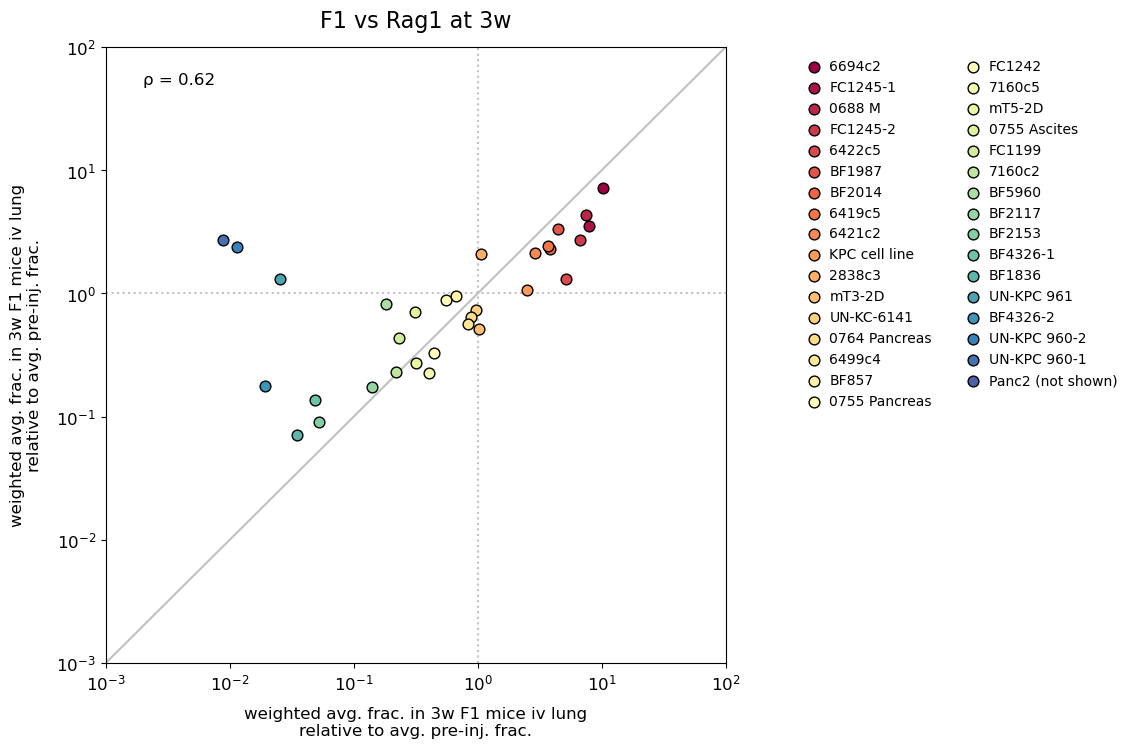

In [193]:
# 1. f1 vs rag 1 at 3w

plt.figure(figsize=(8, 8))

xs = []; ys = []
for count, i in enumerate(clIDs_ordered):
        
    if clID_dict[i] == 'Panc2':
        label = 'Panc2 (not shown)'
    else:
        label = clID_dict[i].replace('_', ' ')
    
    norm = avg_fracs_pre_inj[i]
        
    x = weighted_avg_fracs_iv_3w_f1_lung[i] / norm
    y = weighted_avg_fracs_iv_3w_rag1_lung[i] / norm
         
    plt.scatter(x, y, color=colors.to_rgba(count), edgecolor='black', s=60, alpha=1, label=label, zorder=2)
    
    #if x >= 0.9 and y >= 0.9:
     #   plt.text(0.8 * x, 0.6 * y, label, color='#c1c1c1')
    
    if clID_dict[i] != 'Panc2':    
        xs.append(x)
        ys.append(y)
    
plt.plot([1e-3, 1e2], [1e-3, 1e2], color='#c1c1c1', zorder=0)
plt.plot([1, 1], [1e-3, 1e2], ':', color='#c1c1c1', zorder=0)
plt.plot([1e-3, 1e2], [1, 1], ':', color='#c1c1c1', zorder=0)

spearman_r = sp.stats.spearmanr(xs, ys) # rank correlation coefficient
plt.text(2e-3, 5e1, 'ρ = ' + '{0:.2f}'.format(spearman_r[0]), size=12)


plt.xscale('log'); plt.minorticks_off()  
plt.yscale('log'); plt.minorticks_off()
plt.xlim(1e-3, 1e2);
plt.ylim(1e-3, 1e2);

plt.xticks(size=12)
plt.yticks(size=12)

plt.xlabel('weighted avg. frac. in 3w F1 mice iv lung\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);
plt.ylabel('weighted avg. frac. in 3w F1 mice iv lung\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);

plt.title('F1 vs Rag1 at 3w', fontsize=16, pad=14)

plt.legend(frameon=False, ncol=2, handletextpad=0.1, bbox_to_anchor=(1.1, 1));

#plt.savefig('../Data/cell-line-level/oct_plots/3w_f1_vs_rag1_weighted.png', dpi=300, bbox_inches='tight')

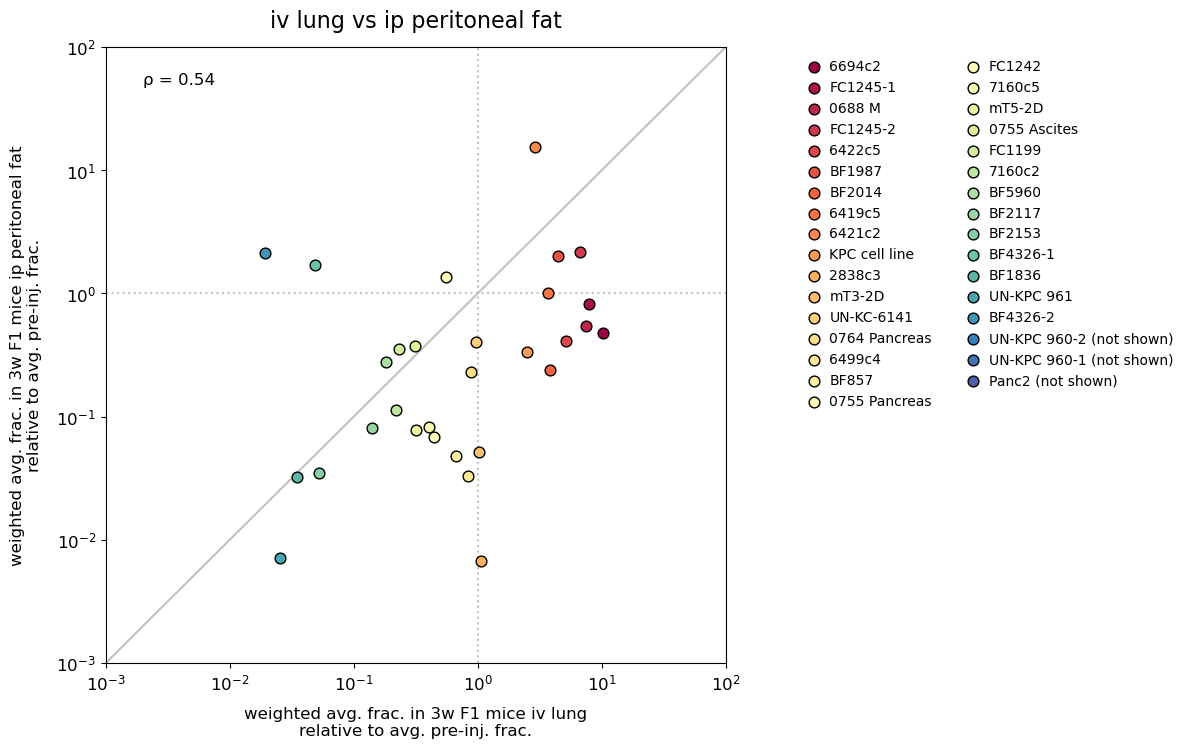

In [194]:
# 2

plt.figure(figsize=(8, 8))

xs = []; ys = []
for count, i in enumerate(clIDs_ordered):
        
    if clID_dict[i] in ['Panc2', 'UN-KPC_960-1', 'UN-KPC_960-2']:
        label = clID_dict[i].replace('_', ' ') + ' (not shown)'
    else:
        label = clID_dict[i].replace('_', ' ')
    
    norm = avg_fracs_pre_inj[i]
        
    x = weighted_avg_fracs_iv_3w_f1_lung[i] / norm
    y = weighted_avg_fracs_ip_3w_f1_fat[i] / norm
         
    plt.scatter(x, y, color=colors.to_rgba(count), edgecolor='black', s=60, alpha=1, label=label, zorder=2)
      
    # plt.text(x, y, label)
    
    if clID_dict[i] != ['Panc2', 'UN-KPC_960-1', 'UN-KPC_960-2']:    
        xs.append(x)
        ys.append(y)
    
plt.plot([1e-3, 1e2], [1e-3, 1e2], color='#c1c1c1', zorder=0)
plt.plot([1, 1], [1e-3, 1e2], ':', color='#c1c1c1', zorder=0)
plt.plot([1e-3, 1e2], [1, 1], ':', color='#c1c1c1', zorder=0)

spearman_r = sp.stats.spearmanr(xs, ys) # rank correlation coefficient
plt.text(2e-3, 5e1, 'ρ = ' + '{0:.2f}'.format(spearman_r[0]), size=12)


plt.xscale('log'); plt.minorticks_off()  
plt.yscale('log'); plt.minorticks_off()
plt.xlim(1e-3, 1e2);
plt.ylim(1e-3, 1e2);

plt.xticks(size=12)
plt.yticks(size=12)

plt.xlabel('weighted avg. frac. in 3w F1 mice iv lung\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);
plt.ylabel('weighted avg. frac. in 3w F1 mice ip peritoneal fat\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);

plt.title('iv lung vs ip peritoneal fat', fontsize=16, pad=14)

plt.legend(frameon=False, ncol=2, handletextpad=0.1, bbox_to_anchor=(1.1, 1));

#plt.savefig('../Data/cell-line-level/oct_plots/3w_f1_iv_lung_vs_ip_fat_weighted.png', dpi=300, bbox_inches='tight')

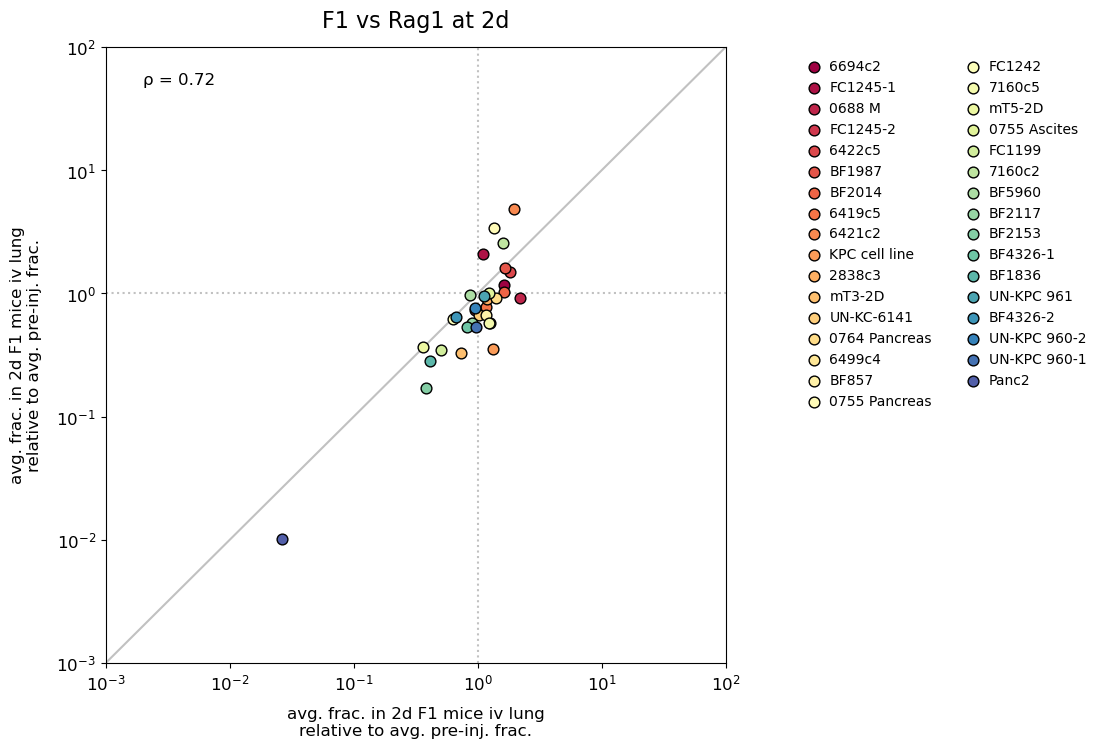

In [195]:
# 3

plt.figure(figsize=(8, 8))

xs = []; ys = []
for count, i in enumerate(clIDs_ordered):
        
    if clID_dict[i] == 'Panc2':
        label = 'Panc2'
    else:
        label = clID_dict[i].replace('_', ' ')
    
    norm = avg_fracs_pre_inj[i]
        
    x = avg_fracs_iv_2d_f1_lung[i] / norm
    y = avg_fracs_iv_2d_rag1_lung[i] / norm
         
    plt.scatter(x, y, color=colors.to_rgba(count), edgecolor='black', s=60, alpha=1, label=label, zorder=2)
      
    # plt.text(x, y, label)
    
    if clID_dict[i] != 'Panc2':    
        xs.append(x)
        ys.append(y)
    
plt.plot([1e-3, 1e2], [1e-3, 1e2], color='#c1c1c1', zorder=0)
plt.plot([1, 1], [1e-3, 1e2], ':', color='#c1c1c1', zorder=0)
plt.plot([1e-3, 1e2], [1, 1], ':', color='#c1c1c1', zorder=0)

spearman_r = sp.stats.spearmanr(xs, ys) # rank correlation coefficient
plt.text(2e-3, 5e1, 'ρ = ' + '{0:.2f}'.format(spearman_r[0]), size=12)


plt.xscale('log'); plt.minorticks_off()  
plt.yscale('log'); plt.minorticks_off()
plt.xlim(1e-3, 1e2);
plt.ylim(1e-3, 1e2);

plt.xticks(size=12)
plt.yticks(size=12)

plt.xlabel('avg. frac. in 2d F1 mice iv lung\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);
plt.ylabel('avg. frac. in 2d F1 mice iv lung\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);

plt.title('F1 vs Rag1 at 2d', fontsize=16, pad=14)

plt.legend(frameon=False, ncol=2, handletextpad=0.1, bbox_to_anchor=(1.1, 1));

#plt.savefig('../Data/cell-line-level/oct_plots/2d_f1_vs_rag1.png', dpi=300, bbox_inches='tight')

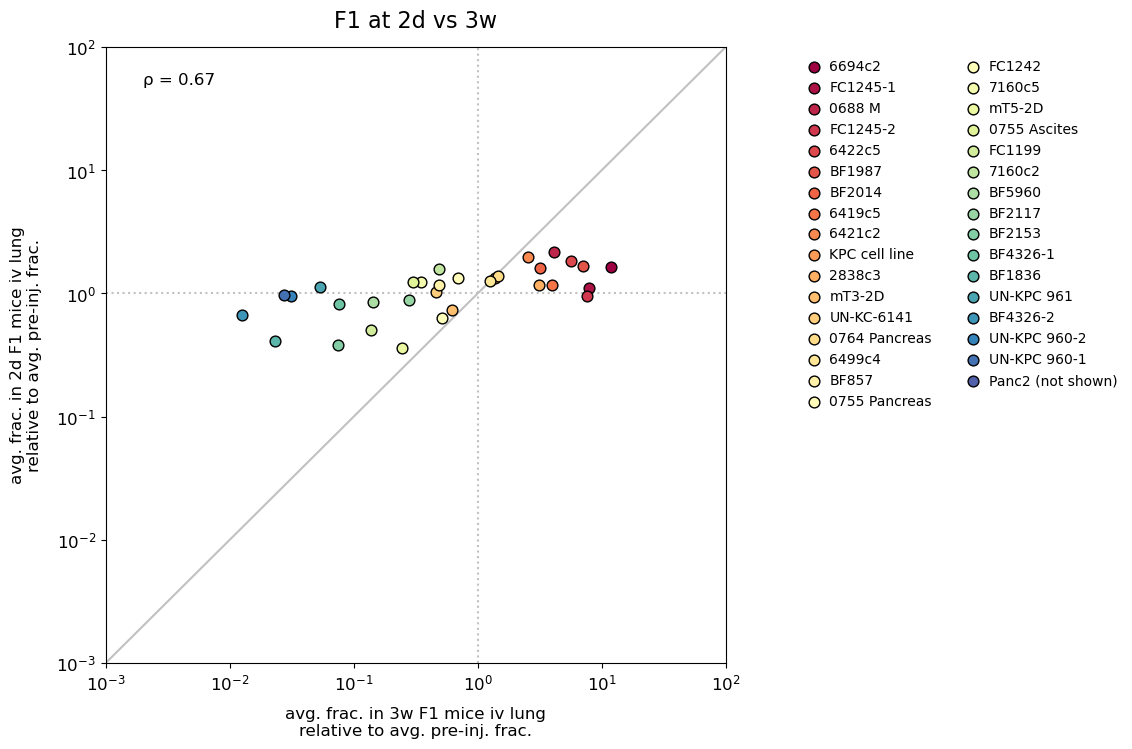

In [196]:
# 4

plt.figure(figsize=(8, 8))

xs = []; ys = []
for count, i in enumerate(clIDs_ordered):
        
    if clID_dict[i] == 'Panc2':
        label = 'Panc2 (not shown)'
    else:
        label = clID_dict[i].replace('_', ' ')
    
    norm = avg_fracs_pre_inj[i]
        
    x = avg_fracs_iv_3w_f1_lung[i] / norm
    y = avg_fracs_iv_2d_f1_lung[i] / norm
         
    plt.scatter(x, y, color=colors.to_rgba(count), edgecolor='black', s=60, alpha=1, label=label, zorder=2)
      
    # plt.text(x, y, label)
    
    if clID_dict[i] != 'Panc2':    
        xs.append(x)
        ys.append(y)
    
plt.plot([1e-3, 1e2], [1e-3, 1e2], color='#c1c1c1', zorder=0)
plt.plot([1, 1], [1e-3, 1e2], ':', color='#c1c1c1', zorder=0)
plt.plot([1e-3, 1e2], [1, 1], ':', color='#c1c1c1', zorder=0)

spearman_r = sp.stats.spearmanr(xs, ys) # rank correlation coefficient
plt.text(2e-3, 5e1, 'ρ = ' + '{0:.2f}'.format(spearman_r[0]), size=12)


plt.xscale('log'); plt.minorticks_off()  
plt.yscale('log'); plt.minorticks_off()
plt.xlim(1e-3, 1e2);
plt.ylim(1e-3, 1e2);

plt.xticks(size=12)
plt.yticks(size=12)

plt.xlabel('avg. frac. in 3w F1 mice iv lung\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);
plt.ylabel('avg. frac. in 2d F1 mice iv lung\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);

plt.title('F1 at 2d vs 3w', fontsize=16, pad=14)

plt.legend(frameon=False, ncol=2, handletextpad=0.1, bbox_to_anchor=(1.1, 1));

#plt.savefig('../Data/cell-line-level/oct_plots/F1_at_2d_vs_3w.png', dpi=300, bbox_inches='tight')

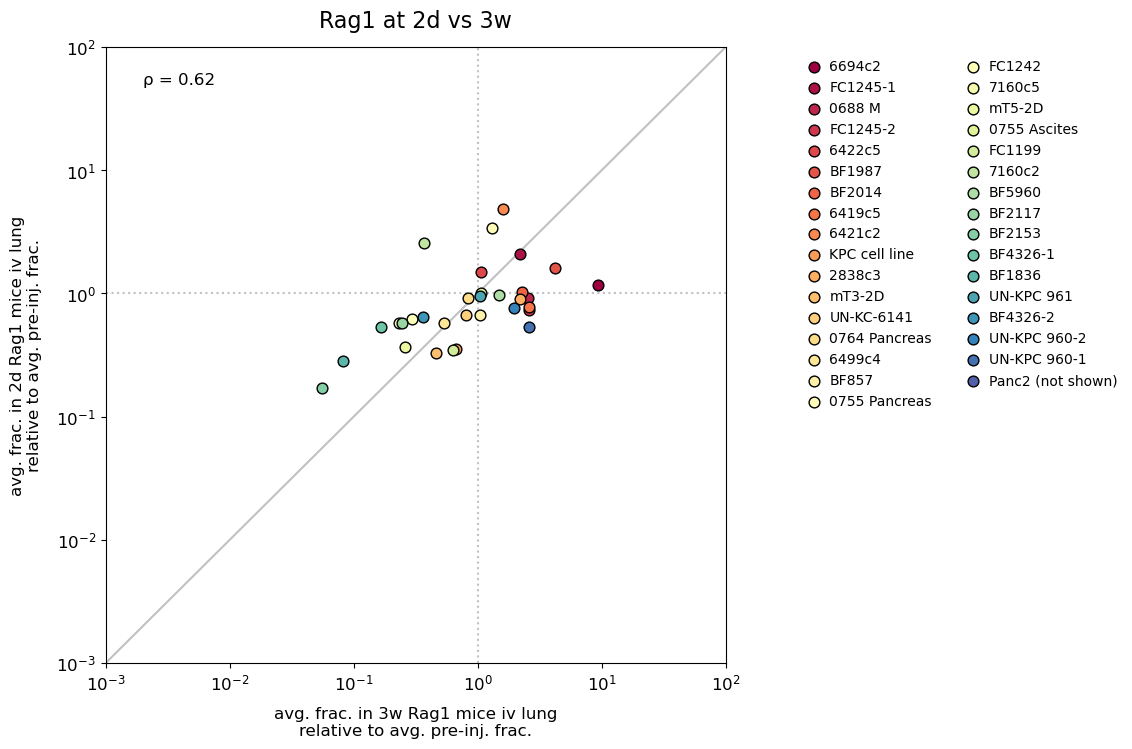

In [197]:
# 5

plt.figure(figsize=(8, 8))

xs = []; ys = []
for count, i in enumerate(clIDs_ordered):
        
    if clID_dict[i] == 'Panc2':
        label = 'Panc2 (not shown)'
    else:
        label = clID_dict[i].replace('_', ' ')
    
    norm = avg_fracs_pre_inj[i]
        
    x = avg_fracs_iv_3w_rag1_lung[i] / norm
    y = avg_fracs_iv_2d_rag1_lung[i] / norm
         
    plt.scatter(x, y, color=colors.to_rgba(count), edgecolor='black', s=60, alpha=1, label=label, zorder=2)
      
    # plt.text(x, y, label)
    
    if clID_dict[i] != 'Panc2':    
        xs.append(x)
        ys.append(y)
    
plt.plot([1e-3, 1e2], [1e-3, 1e2], color='#c1c1c1', zorder=0)
plt.plot([1, 1], [1e-3, 1e2], ':', color='#c1c1c1', zorder=0)
plt.plot([1e-3, 1e2], [1, 1], ':', color='#c1c1c1', zorder=0)

spearman_r = sp.stats.spearmanr(xs, ys) # rank correlation coefficient
plt.text(2e-3, 5e1, 'ρ = ' + '{0:.2f}'.format(spearman_r[0]), size=12)


plt.xscale('log'); plt.minorticks_off()  
plt.yscale('log'); plt.minorticks_off()
plt.xlim(1e-3, 1e2);
plt.ylim(1e-3, 1e2);

plt.xticks(size=12)
plt.yticks(size=12)

plt.xlabel('avg. frac. in 3w Rag1 mice iv lung\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);
plt.ylabel('avg. frac. in 2d Rag1 mice iv lung\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);

plt.title('Rag1 at 2d vs 3w', fontsize=16, pad=14)

plt.legend(frameon=False, ncol=2, handletextpad=0.1, bbox_to_anchor=(1.1, 1));

#plt.savefig('../Data/cell-line-level/oct_plots/Rag1_at_2d_vs_3w.png', dpi=300, bbox_inches='tight')

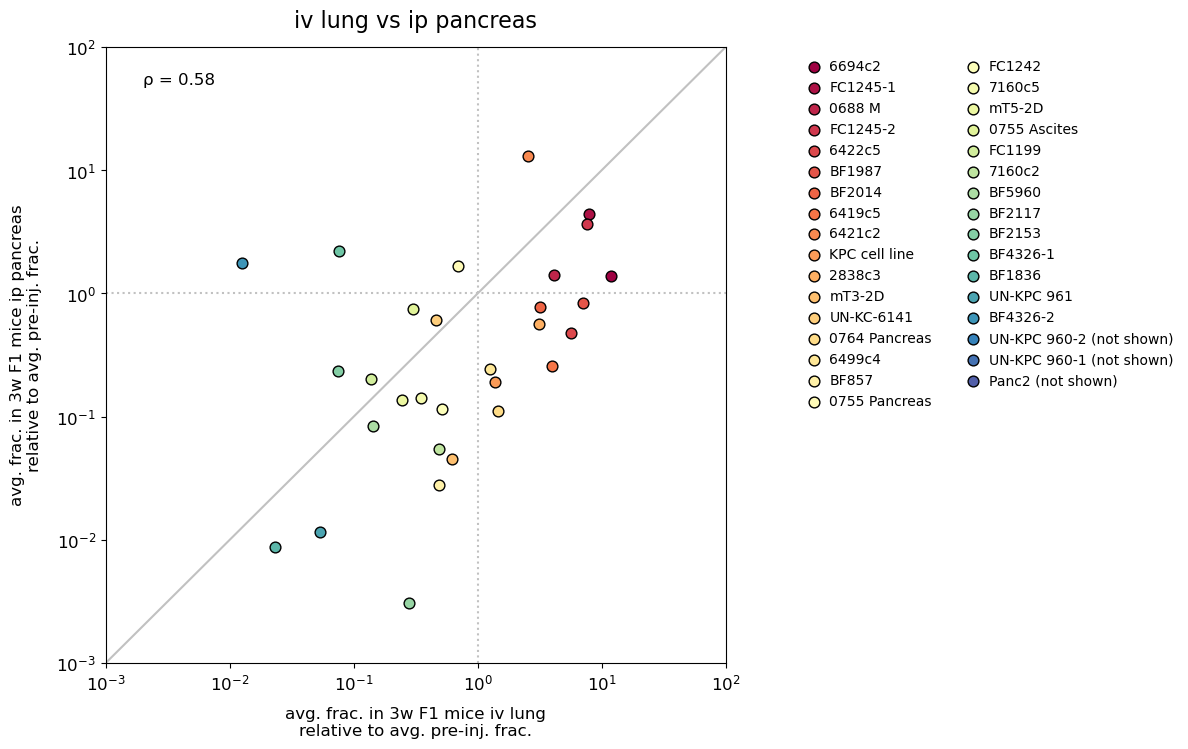

In [198]:
# 9

plt.figure(figsize=(8, 8))

xs = []; ys = []
for count, i in enumerate(clIDs_ordered):
        
    if clID_dict[i] in ['Panc2', 'UN-KPC_960-1', 'UN-KPC_960-2']:
        label = clID_dict[i].replace('_', ' ') + ' (not shown)'
    else:
        label = clID_dict[i].replace('_', ' ')
    
    norm = avg_fracs_pre_inj[i]
        
    x = avg_fracs_iv_3w_f1_lung[i] / norm
    y = avg_fracs_ip_3w_f1_panc[i] / norm
         
    plt.scatter(x, y, color=colors.to_rgba(count), edgecolor='black', s=60, alpha=1, label=label, zorder=2)
      
    # plt.text(x, y, label)
    
    if clID_dict[i] != ['Panc2', 'UN-KPC_960-1', 'UN-KPC_960-2']:    
        xs.append(x)
        ys.append(y)
    
plt.plot([1e-3, 1e2], [1e-3, 1e2], color='#c1c1c1', zorder=0)
plt.plot([1, 1], [1e-3, 1e2], ':', color='#c1c1c1', zorder=0)
plt.plot([1e-3, 1e2], [1, 1], ':', color='#c1c1c1', zorder=0)

spearman_r = sp.stats.spearmanr(xs, ys) # rank correlation coefficient
plt.text(2e-3, 5e1, 'ρ = ' + '{0:.2f}'.format(spearman_r[0]), size=12)


plt.xscale('log'); plt.minorticks_off()  
plt.yscale('log'); plt.minorticks_off()
plt.xlim(1e-3, 1e2);
plt.ylim(1e-3, 1e2);

plt.xticks(size=12)
plt.yticks(size=12)

plt.xlabel('avg. frac. in 3w F1 mice iv lung\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);
plt.ylabel('avg. frac. in 3w F1 mice ip pancreas\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);

plt.title('iv lung vs ip pancreas', fontsize=16, pad=14)

plt.legend(frameon=False, ncol=2, handletextpad=0.1, bbox_to_anchor=(1.1, 1));

#plt.savefig('../Data/cell-line-level/oct_plots/iv_lung_vs_iv_panc.png', dpi=300, bbox_inches='tight')

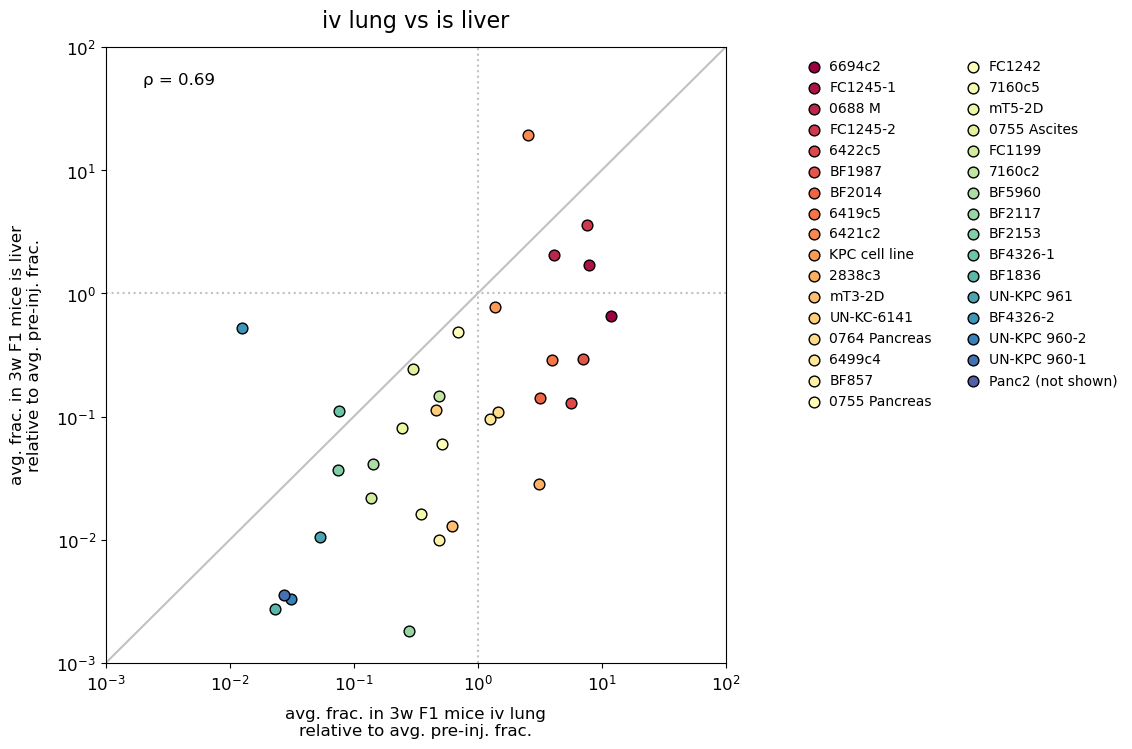

In [199]:
# 10

plt.figure(figsize=(8, 8))

xs = []; ys = []
for count, i in enumerate(clIDs_ordered):
        
    if clID_dict[i] in ['Panc2']:
        label = clID_dict[i].replace('_', ' ') + ' (not shown)'
    else:
        label = clID_dict[i].replace('_', ' ')
    
    norm = avg_fracs_pre_inj[i]
        
    x = avg_fracs_iv_3w_f1_lung[i] / norm
    y = avg_fracs_is_3w_f1_liver[i] / norm
         
    plt.scatter(x, y, color=colors.to_rgba(count), edgecolor='black', s=60, alpha=1, label=label, zorder=2)
      
    # plt.text(x, y, label)
    
    if clID_dict[i] != ['Panc2']:    
        xs.append(x)
        ys.append(y)
    
plt.plot([1e-3, 1e2], [1e-3, 1e2], color='#c1c1c1', zorder=0)
plt.plot([1, 1], [1e-3, 1e2], ':', color='#c1c1c1', zorder=0)
plt.plot([1e-3, 1e2], [1, 1], ':', color='#c1c1c1', zorder=0)

spearman_r = sp.stats.spearmanr(xs, ys) # rank correlation coefficient
plt.text(2e-3, 5e1, 'ρ = ' + '{0:.2f}'.format(spearman_r[0]), size=12)


plt.xscale('log'); plt.minorticks_off()  
plt.yscale('log'); plt.minorticks_off()
plt.xlim(1e-3, 1e2);
plt.ylim(1e-3, 1e2);

plt.xticks(size=12)
plt.yticks(size=12)

plt.xlabel('avg. frac. in 3w F1 mice iv lung\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);
plt.ylabel('avg. frac. in 3w F1 mice is liver\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);

plt.title('iv lung vs is liver', fontsize=16, pad=14)

plt.legend(frameon=False, ncol=2, handletextpad=0.1, bbox_to_anchor=(1.1, 1));

#plt.savefig('../Data/cell-line-level/oct_plots/iv_lung_vs_is_liver.png', dpi=300, bbox_inches='tight')

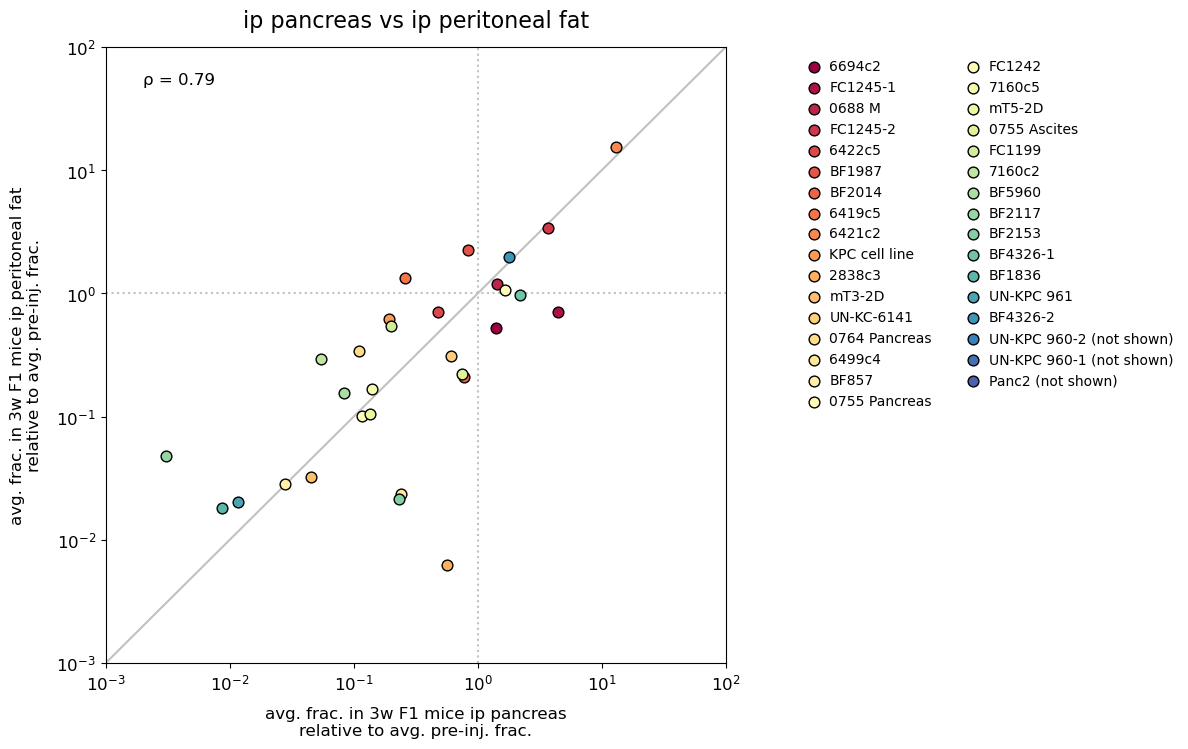

In [200]:
# 6

plt.figure(figsize=(8, 8))

xs = []; ys = []
for count, i in enumerate(clIDs_ordered):
        
    if clID_dict[i] in ['Panc2', 'UN-KPC_960-1', 'UN-KPC_960-2']:
        label = clID_dict[i].replace('_', ' ') + ' (not shown)'
    else:
        label = clID_dict[i].replace('_', ' ')
    
    norm = avg_fracs_pre_inj[i]
        
    x = avg_fracs_ip_3w_f1_panc[i] / norm
    y = avg_fracs_ip_3w_f1_fat[i] / norm
         
    plt.scatter(x, y, color=colors.to_rgba(count), edgecolor='black', s=60, alpha=1, label=label, zorder=2)
      
    # plt.text(x, y, label)
    
    if clID_dict[i] != ['Panc2', 'UN-KPC_960-1', 'UN-KPC_960-2']:    
        xs.append(x)
        ys.append(y)
    
plt.plot([1e-3, 1e2], [1e-3, 1e2], color='#c1c1c1', zorder=0)
plt.plot([1, 1], [1e-3, 1e2], ':', color='#c1c1c1', zorder=0)
plt.plot([1e-3, 1e2], [1, 1], ':', color='#c1c1c1', zorder=0)

spearman_r = sp.stats.spearmanr(xs, ys) # rank correlation coefficient
plt.text(2e-3, 5e1, 'ρ = ' + '{0:.2f}'.format(spearman_r[0]), size=12)


plt.xscale('log'); plt.minorticks_off()  
plt.yscale('log'); plt.minorticks_off()
plt.xlim(1e-3, 1e2);
plt.ylim(1e-3, 1e2);

plt.xticks(size=12)
plt.yticks(size=12)

plt.xlabel('avg. frac. in 3w F1 mice ip pancreas\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);
plt.ylabel('avg. frac. in 3w F1 mice ip peritoneal fat\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);

plt.title('ip pancreas vs ip peritoneal fat', fontsize=16, pad=14)

plt.legend(frameon=False, ncol=2, handletextpad=0.1, bbox_to_anchor=(1.1, 1));

#plt.savefig('../Data/cell-line-level/oct_plots/ip_panc_vs_ip_fat.png', dpi=300, bbox_inches='tight')

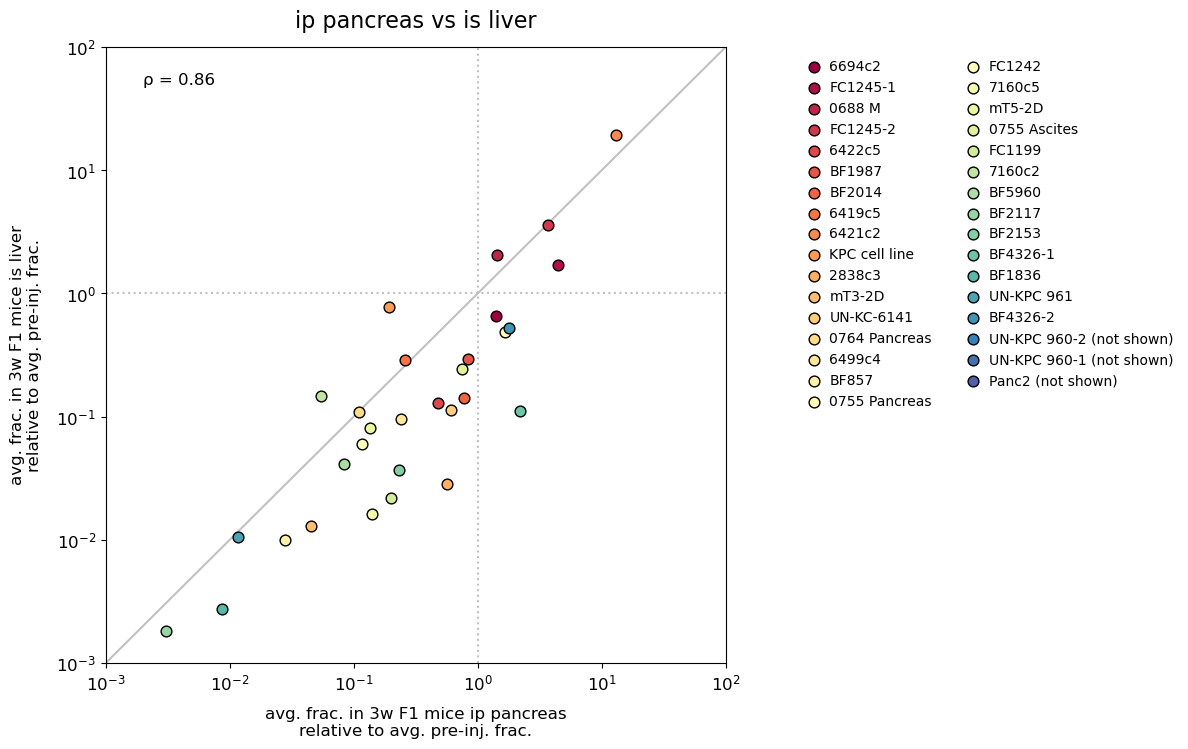

In [203]:
# 7

plt.figure(figsize=(8, 8))

xs = []; ys = []
for count, i in enumerate(clIDs_ordered):
        
    if clID_dict[i] in ['Panc2', 'UN-KPC_960-1', 'UN-KPC_960-2']:
        label = clID_dict[i].replace('_', ' ') + ' (not shown)'
    else:
        label = clID_dict[i].replace('_', ' ')
    
    norm = avg_fracs_pre_inj[i]
        
    x = avg_fracs_ip_3w_f1_panc[i] / norm
    y = avg_fracs_is_3w_f1_liver[i] / norm
         
    plt.scatter(x, y, color=colors.to_rgba(count), edgecolor='black', s=60, alpha=1, label=label, zorder=2)
      
    # plt.text(x, y, label)
    
    if clID_dict[i] != ['Panc2', 'UN-KPC_960-1', 'UN-KPC_960-2']:    
        xs.append(x)
        ys.append(y)
    
plt.plot([1e-3, 1e2], [1e-3, 1e2], color='#c1c1c1', zorder=0)
plt.plot([1, 1], [1e-3, 1e2], ':', color='#c1c1c1', zorder=0)
plt.plot([1e-3, 1e2], [1, 1], ':', color='#c1c1c1', zorder=0)

spearman_r = sp.stats.spearmanr(xs, ys) # rank correlation coefficient
plt.text(2e-3, 5e1, 'ρ = ' + '{0:.2f}'.format(spearman_r[0]), size=12)


plt.xscale('log'); plt.minorticks_off()  
plt.yscale('log'); plt.minorticks_off()
plt.xlim(1e-3, 1e2);
plt.ylim(1e-3, 1e2);

plt.xticks(size=12)
plt.yticks(size=12)

plt.xlabel('avg. frac. in 3w F1 mice ip pancreas\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);
plt.ylabel('avg. frac. in 3w F1 mice is liver\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);

plt.title('ip pancreas vs is liver', fontsize=16, pad=14)

plt.legend(frameon=False, ncol=2, handletextpad=0.1, bbox_to_anchor=(1.1, 1));

#plt.savefig('../Data/cell-line-level/oct_plots/ip_panc_vs_is_liver.png', dpi=300, bbox_inches='tight')

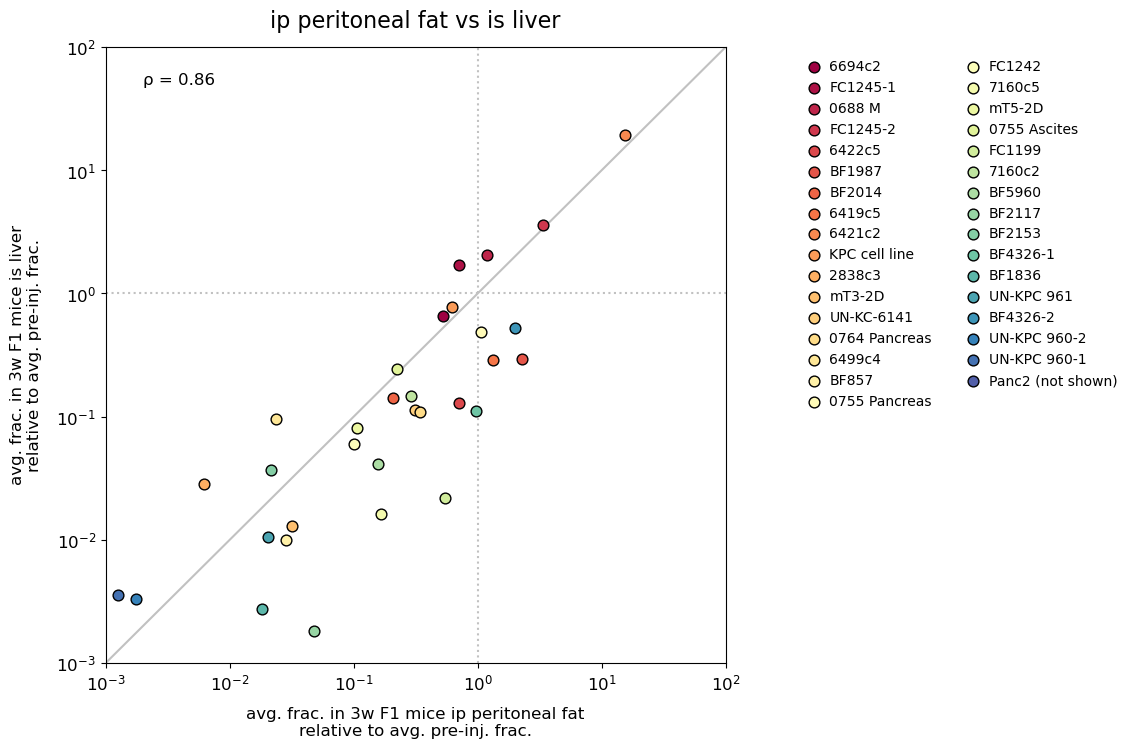

In [207]:
# 7

plt.figure(figsize=(8, 8))

xs = []; ys = []
for count, i in enumerate(clIDs_ordered):
        
    if clID_dict[i] in ['Panc2']:
        label = clID_dict[i].replace('_', ' ') + ' (not shown)'
    else:
        label = clID_dict[i].replace('_', ' ')
    
    norm = avg_fracs_pre_inj[i]
        
    x = avg_fracs_ip_3w_f1_fat[i] / norm
    y = avg_fracs_is_3w_f1_liver[i] / norm
         
    plt.scatter(x, y, color=colors.to_rgba(count), edgecolor='black', s=60, alpha=1, label=label, zorder=2)
      
    # plt.text(x, y, label)
    
    if clID_dict[i] != ['Panc2']:    
        xs.append(x)
        ys.append(y)
    
plt.plot([1e-3, 1e2], [1e-3, 1e2], color='#c1c1c1', zorder=0)
plt.plot([1, 1], [1e-3, 1e2], ':', color='#c1c1c1', zorder=0)
plt.plot([1e-3, 1e2], [1, 1], ':', color='#c1c1c1', zorder=0)

spearman_r = sp.stats.spearmanr(xs, ys) # rank correlation coefficient
plt.text(2e-3, 5e1, 'ρ = ' + '{0:.2f}'.format(spearman_r[0]), size=12)


plt.xscale('log'); plt.minorticks_off()  
plt.yscale('log'); plt.minorticks_off()
plt.xlim(1e-3, 1e2);
plt.ylim(1e-3, 1e2);

plt.xticks(size=12)
plt.yticks(size=12)

plt.xlabel('avg. frac. in 3w F1 mice ip peritoneal fat\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);
plt.ylabel('avg. frac. in 3w F1 mice is liver\nrelative to avg. pre-inj. frac.', fontsize=12, labelpad=10);

plt.title('ip peritoneal fat vs is liver', fontsize=16, pad=14)

plt.legend(frameon=False, ncol=2, handletextpad=0.1, bbox_to_anchor=(1.1, 1));

#plt.savefig('../Data/cell-line-level/oct_plots/ip_fat_vs_is_liver.png', dpi=300, bbox_inches='tight')

In [214]:
# ordering cell lines by avg 3w f1 iv lung weighted frac relative to pre-injection
tmp = []
for i in clIDs[1:]: # excluding spike-in
    tmp.append([i, avg_fracs_iv_3w_f1_panc[i]]) 

In [215]:
clIDs_ordered_2 = [y[0] for y in sorted(tmp, key = lambda x: x[-1], reverse=True)]

In [216]:
colors_2 = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(clIDs_ordered_2)), 
                                      cmap=plt.get_cmap('Spectral'))


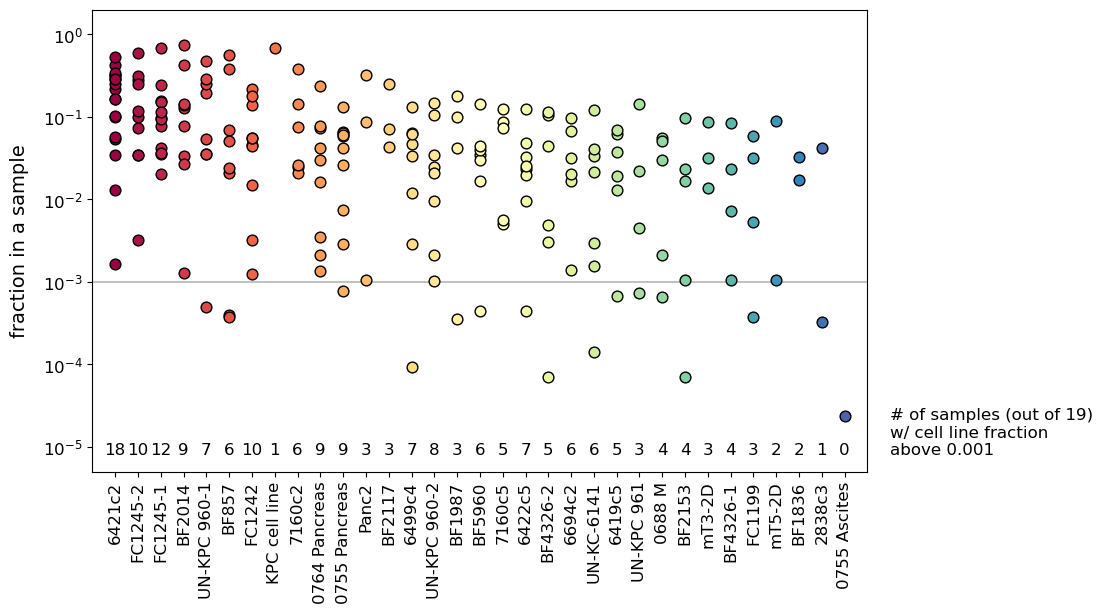

In [245]:
# iv pancreas samples

plt.figure(figsize=(10, 6));

sample_counts = [0 for x in range(len(clIDs_ordered_2))]
for sample in samples_iv_3w_f1_panc:
    
    #xs = []; ys = []
    for c, clID in enumerate(clIDs_ordered_2):
        
        y = n_reads[sample][clID] / sum(n_reads[sample][1:])
        plt.scatter(c, y, color=colors_2.to_rgba(c), s=60, edgecolor='black')
        
        if y >= 0.001:
            sample_counts[c] += 1
        
        #ys.append(y)
        #xs.append(c)
        
    #plt.plot(xs, ys, color='#c1c1c1')
    
plt.axhline(1e-3, color='#c1c1c1', zorder=-1)
plt.text(34, 0.8e-5, '# of samples (out of 19)\nw/ cell line fraction\nabove 0.001', size=12)

for c in range(len(clIDs_ordered_2)):
    plt.text(c, 0.8e-5, sample_counts[c], ha='center', size=12)

    
plt.yscale('log')
plt.minorticks_off();

plt.ylim(5e-6, 2e0);
plt.xlim(-1, 33);

plt.xticks(range(len(clIDs_ordered_2)), [clID_dict[x].replace('_', ' ') for x in clIDs_ordered_2], rotation=90, size=12);
plt.yticks(size=12);

plt.ylabel('fraction in a sample', fontsize=14, labelpad=10);

#plt.savefig('../Data/cell-line-level/oct_plots/iv_panc.png', dpi=300, bbox_inches='tight')


In [229]:
len(samples_iv_3w_f1_panc)

19